<a href="https://colab.research.google.com/github/t0bleronee/BEE-102-Spring-2025-Assignment/blob/main/06_PCA_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Q6: Principle Component Analysis



## **Part 1: Visualizing GATA3 vs. XBP1 Expression – Figure a**

### **Objective**

To plot expression levels of **GATA3** and **XBP1** across 105 breast cancer samples, highlighting **ER status** (ER− = 0, ER+ = 1), and observe any potential natural separation between the two classes.

### **Step-by-Step**

1. **Data Loading**:

   * Import three datasets:

     * `filtered.tsv` – expression matrix (samples × genes).
     * `columns.tsv` – gene annotations to map IDs to symbols.
     * `class.tsv` – binary ER status labels for each sample.
   * Clean and strip column headers to ensure proper formatting.

2. **Gene Identification**:

   * Extract unique IDs for **GATA3** and **XBP1** using the `GeneSymbol` column in `columns.tsv`.
   * Use these IDs to access expression vectors for both genes.

3. **Scatter Plot**:

   * Use GATA3 values for x-axis and XBP1 for y-axis.
   * Color-code points:

     * **Red** for ER+ (label 1),
     * **Black** for ER− (label 0).
   * Plot shows the raw expression distribution, potentially revealing expression-based separation.

4. **Biological Insight**:

   * GATA3 and XBP1 are known markers in breast cancer subtypes.
   * Early indication of ER+ clustering at higher GATA3 expression suggests potential discriminative power.



## **Part 2: PCA on GATA3 and XBP1 – Figures b and c**

### **Objective**

To apply **Principal Component Analysis (PCA)** on GATA3/XBP1 expression values, and visualize the principal axes and 1D projection, providing a clearer, label-independent grouping.

### **Step-by-Step**

1. **Why PCA?**

   * PCA helps reduce correlated 2D gene expression data into **orthogonal components** (PC1, PC2).
   * It finds directions capturing maximum variance without using class labels (unsupervised).

2. **PCA Implementation**:

   * Apply PCA to the 2D matrix (GATA3, XBP1).
   * Extract:

     * **PC1** – primary axis of variance,
     * **PC2** – orthogonal secondary axis.

3. **Figure b – Visualizing PCA Axes**:

   * Scatter plot of original data.
   * Overlay arrows showing PC1 and PC2 directions, scaled relative to data range.
   * Annotate each axis to illustrate PCA orientation.

4. **Figure c – Projection onto PC1**:

   * Project all samples onto PC1 to obtain 1D representations.
   * Create horizontal strip plots showing:

     * **All samples**
     * **ER− samples**
     * **ER+ samples**
   * Each sample is plotted based on its PC1 value and color-coded accordingly.

5. **Biological Insight**:

   * The projection reveals a **clearer distinction** between ER+ and ER− classes along PC1 than in the raw 2D space.
   * This supports the utility of unsupervised dimensionality reduction in identifying biologically meaningful variance.

6. **Variance Explained**:

   * Print the percentage of variance explained by PC1 and PC2.
   * A high value for PC1 implies it effectively captures dominant trends between ER classes.


## **Part 3: Full Dataset PCA – Figures d, e, f**

### **Objective**

To generalize PCA over the full gene expression matrix and explore global structure in the dataset.

### **Step-by-Step**

1. **Full PCA**:

   * Normalize the entire expression dataset using `StandardScaler`.
   * Apply PCA to obtain transformed principal component space (`X_pca`).

2. **Figure d – Scree Plot**:

   * Bar plot of variance explained by each principal component.
   * Shows how much each PC contributes to total variation.
   * Typically, PC1 and PC2 explain the bulk of meaningful variation.

3. **Figure e – PCA Scatter with Gene Vectors**:

   * Scatter plot of samples in PC1 vs. PC2 space.
   * Overlay directional vectors representing known genes (e.g., XBP1, CCNB2).
   * Vectors indicate the direction and magnitude of gene loading on PCA axes.

4. **Figure f – PCA Colored by ER Status**:

   * Same PCA scatter (PC1 vs. PC2), recolored:

     * **Orange** for ER+,
     * **Blue** for ER−.
   * Provides additional confirmation of class separation in PCA space.



Labels shape: (105, 1)
Expression shape: (105, 16174)


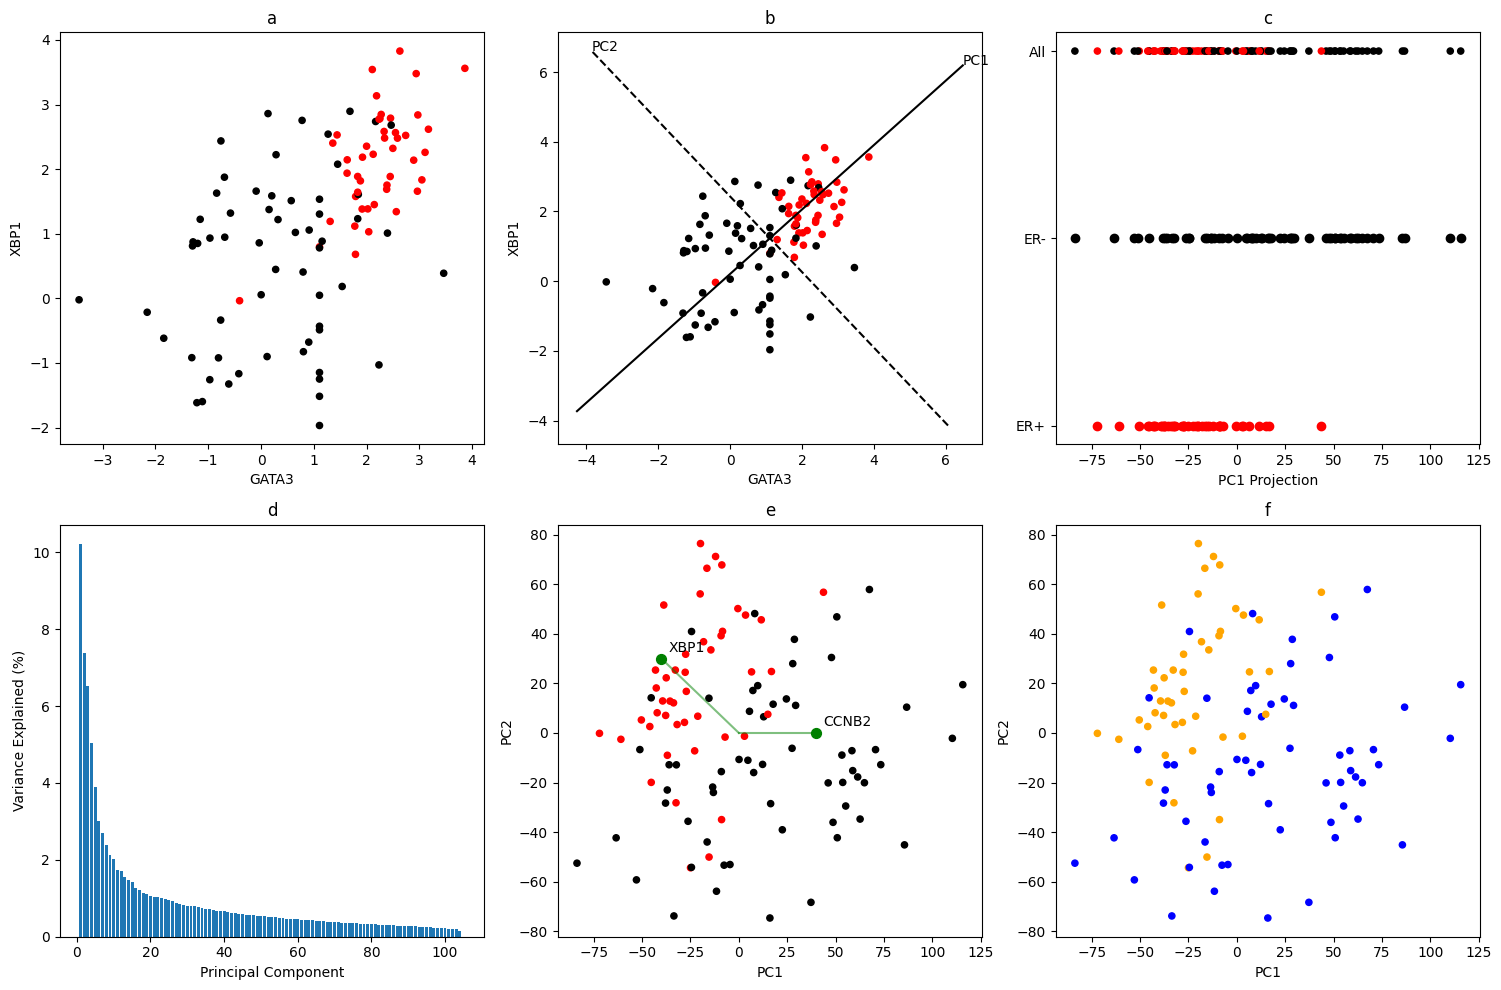


PC1 variance: 0.102
PC2 variance: 0.074


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

np.random.seed(42)

try:
    labels_df = pd.read_csv('class.tsv', sep='\t', header=None)
    print("Labels shape:", labels_df.shape)

    expr_df = pd.read_csv('filtered.tsv', sep='\t')
    print("Expression shape:", expr_df.shape)

    expr_df.columns = expr_df.columns.str.strip()

    col_headers = ['ID', 'TYPE', 'ReporterID', 'GeneName', 'GeneSymbol', 'UniGeneCluster',
                   'UniGeneBuild', 'GB_LIST', 'EntrezGene', 'vector', 'InsertLength',
                   'ARRAY_BLOCK', 'BLOCK_COLUMN', 'BLOCK_ROW', 'SPOT_ID', 'CLONE_ID']

    gene_info = pd.read_csv('columns.tsv', sep='\t', names=col_headers, skiprows=1)

    plt.figure(figsize=(15, 10))

    data_matrix = expr_df.values
    standardized = StandardScaler().fit_transform(data_matrix)

    full_pca = PCA()
    pca_result = full_pca.fit_transform(standardized)

    def map_gene_id(symbol):
        match = gene_info[gene_info['GeneSymbol'] == symbol]
        return str(match['ID'].iloc[0]) if not match.empty else None

    xbp1_key = map_gene_id('XBP1')
    gata3_key = map_gene_id('GATA3')

    if xbp1_key and gata3_key:
        xbp1_vals = expr_df[xbp1_key].values
        gata3_vals = expr_df[gata3_key].values

        # Plot a
        plt.subplot(2, 3, 1)
        color_map = ['red' if val == 1 else 'black' for val in labels_df[0]]
        plt.scatter(gata3_vals, xbp1_vals, c=color_map, s=20)
        plt.xlabel('GATA3')
        plt.ylabel('XBP1')
        plt.title('a')

        # Plot b
        plt.subplot(2, 3, 2)
        plt.scatter(gata3_vals, xbp1_vals, c=color_map, s=20)

        origin = np.mean(np.vstack([gata3_vals, xbp1_vals]), axis=1)
        local_pca = PCA().fit(np.column_stack((gata3_vals, xbp1_vals)))

        xy_span = max(np.ptp(gata3_vals), np.ptp(xbp1_vals))

        pc1_vec = local_pca.components_[0]
        pc2_vec = local_pca.components_[1]

        pc1_x = origin[0] + np.array([-1, 1]) * pc1_vec[0] * xy_span
        pc1_y = origin[1] + np.array([-1, 1]) * pc1_vec[1] * xy_span
        pc2_x = origin[0] + np.array([-1, 1]) * pc2_vec[0] * xy_span
        pc2_y = origin[1] + np.array([-1, 1]) * pc2_vec[1] * xy_span

        plt.plot(pc1_x, pc1_y, 'k-', label='PC1')
        plt.plot(pc2_x, pc2_y, 'k--', label='PC2')
        plt.annotate('PC1', (pc1_x[1], pc1_y[1]))
        plt.annotate('PC2', (pc2_x[1], pc2_y[1]))
        plt.xlabel('GATA3')
        plt.ylabel('XBP1')
        plt.title('b')

        # Plot c
        plt.subplot(2, 3, 3)
        y_levels = [2, 1, 0]
        pc1_scores = pca_result[:, 0]
        plt.scatter(pc1_scores, [y_levels[0]] * len(pc1_scores), c=color_map, s=20)
        plt.scatter(pc1_scores[np.array(color_map) == 'black'], [y_levels[1]] * sum(np.array(color_map) == 'black'), c='black')
        plt.scatter(pc1_scores[np.array(color_map) == 'red'], [y_levels[2]] * sum(np.array(color_map) == 'red'), c='red')
        plt.yticks(y_levels, ['All', 'ER-', 'ER+'])
        plt.xlabel('PC1 Projection')
        plt.title('c')

        # Plot d
        plt.subplot(2, 3, 4)
        var_ratio = full_pca.explained_variance_ratio_ * 100
        plt.bar(np.arange(1, len(var_ratio) + 1), var_ratio)
        plt.xlabel('Principal Component')
        plt.ylabel('Variance Explained (%)')
        plt.title('d')

        # Plot e
        plt.subplot(2, 3, 5)
        plt.scatter(pca_result[:, 0], pca_result[:, 1], c=color_map, s=20)
        plt.plot([0, -40], [0, 30], 'g-', alpha=0.5)
        plt.plot([0, 40], [0, 0], 'g-', alpha=0.5)
        plt.scatter([-40, 40], [30, 0], c='green', s=50)
        plt.annotate('XBP1', (-40, 30), xytext=(5, 5), textcoords='offset points')
        plt.annotate('CCNB2', (40, 0), xytext=(5, 5), textcoords='offset points')
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title('e')

        # Plot f
        plt.subplot(2, 3, 6)
        alt_colors = ['orange' if val == 1 else 'blue' for val in labels_df[0]]
        plt.scatter(pca_result[:, 0], pca_result[:, 1], c=alt_colors, s=20)
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title('f')

        plt.tight_layout()
        plt.show()

        print(f"\nPC1 variance: {full_pca.explained_variance_ratio_[0]:.3f}")
        print(f"PC2 variance: {full_pca.explained_variance_ratio_[1]:.3f}")

    else:
        print("\nXBP1 or GATA3 gene not found.")
        print("Available symbols:", gene_info['GeneSymbol'].dropna().unique()[:20])

except Exception as err:
    print("An error occurred:", str(err))
    print("\nShapes:")
    print("Expression:", expr_df.shape)
    print("Labels:", labels_df.shape)
